# 10. Euler's rule continued: energy conservation, subplots, animation


## Recap

To investigate how to deal with the errors from the simulation, last time we had two plans. 

One is to understand how to choose your step size according to the physical problem

<div class="span alert alert-success">
    
The timestep $\Delta t$ should be much smaller compared to the **characteristic timescale $\bf\tau$** of the problem, $\Delta t << \tau$. 

**Exmaple 1.** For throwing a ball in the air, $\tau$ would be the time the ball travels in the air before hitting the ground. 

**Exmaple 2.** For earth revolving around the sun, $\tau$ is on the order of a year. 

**Exmaple 3.** For simulating O2 molecules vibrating while floating around not reacting with each other, $\tau$ is on the order of phonon vibration periods, 2000 cm$^{-1}\approx$ 0.02 ps = 20 fs.
    
A rule of thumb is to use $\Delta t = 0.01 \tau$.

</div>

Today we'll work on our second plan: check energy convervation numerically.


Continuing from our code last time – To see the violation of energy conservation more clearly, let's monitor the energies througout the simulation.

In [ ]:
import numpy as np

def KineticE(v):
    return 0.5*mass*v**2

def PotentialE(zpos):
    return mass*g*zpos

KEn=[]
PEn=[]
TEn=[]

KE = KineticE( np.sqrt(xvel**2 + zvel**2) )
PE = PotentialE( zpos)
KEn.append(KE)
PEn.append(PE)
TEn.append(KE+PE)

NameError: name 'xvel' is not defined

Below is our final version of this project. Here we introduce **subplots** so that we can plot two figures side by side. This is a more advanced way of creating plots, where we can control multiple plots using their axes. In the example below they are labeled ax.

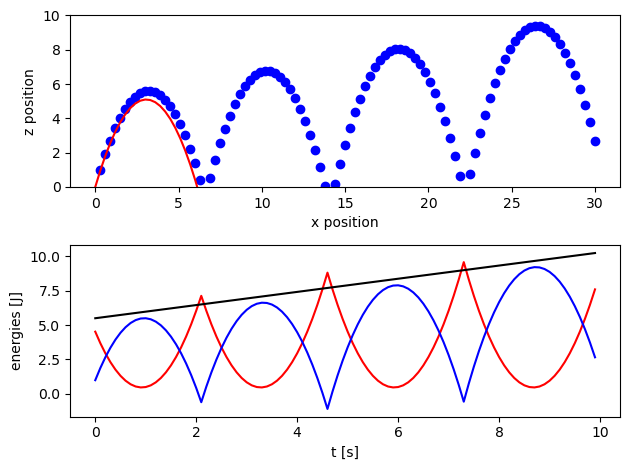

In [9]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.1
t_range = np.arange(0,10,dt)

xpos = 0
xvel = 3
zpos = 0
zvel = 10
zpos_list = []
zvel_list = []
xpos_list = []
g=9.8
mass=0.1

def KineticE(v):
    return 0.5*mass*v**2

def PotentialE(zpos):
    return mass*g*zpos

KEn=[]
PEn=[]
TEn=[]
    

def move(zpos,zvel, xpos, xvel):
    zpos += zvel* dt
    zvel -= g*dt
    xpos += xvel *dt
    return zpos, zvel, xpos, xvel

xa = [xvel*t for t in t_range]
za = [zvel*t - 0.5*g*t**2 for t in t_range]

for t in t_range:
    zpos, zvel, xpos, xvel = move(zpos, zvel,xpos, xvel)
    if zpos < 0 : 
        zvel = -zvel      
    zvel_list.append(zvel)
    xpos_list.append(xpos)
    zpos_list.append(zpos)
    KE = KineticE( np.sqrt(xvel**2 + zvel**2) )
    PE = PotentialE( zpos)
    KEn.append(KE)
    PEn.append(PE)
    TEn.append(KE+PE )


#plotting
#plotting numerical
fig, ax = plt.subplots(2)
ax[0].plot(xpos_list,zpos_list,'bo')
ax[0].plot(xa,za,'r-')
ax[0].set_ylim(0,10)
ax[0].set_ylabel('z position')
ax[0].set_xlabel('x position')

#plotting analytical
ax[1].plot(t_range,KEn,'r-')
ax[1].plot(t_range,PEn,'b-')
ax[1].plot(t_range,TEn,'k-')
ax[1].set_ylabel('energies [J]')
ax[1].set_xlabel('t [s]')

plt.tight_layout()
plt.show()

# Spring Oscillator

## The Physical System

A mass $m$ attached to a spring with spring constant $k$ follows Hooke's Law:

$$F = -kx$$

Using Newton's second law ($F = ma$):

$$ma = -kx$$

$$a = -\frac{k}{m}x$$

This creates **simple harmonic motion** with angular frequency $\omega = \sqrt{k/m}$.

### Energy Conservation

The total energy should remain constant:

$$ E_{total} = \frac{1}{2}mv^2 + \frac{1}{2}kx^2 $$

(kinetic energy + potential energy)